In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import XGBClassifier
import joblib
import shap

In [5]:
data = load_breast_cancer()

In [6]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [10]:
X= pd.DataFrame(data.data, columns=data.feature_names)
y= pd.Series(data.target)

In [11]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [12]:
y

,0
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [14]:
print("Shape:", X.shape)
print("Class counts:\n", y.value_counts(normalize=True))

Shape: (569, 30)
Class counts:
 1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [16]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (364, 30) Val: (91, 30) Test: (114, 30)


In [18]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=20
)

[0]	validation_0-logloss:0.62187
[20]	validation_0-logloss:0.26142
[40]	validation_0-logloss:0.16966
[60]	validation_0-logloss:0.14088
[80]	validation_0-logloss:0.13126
[100]	validation_0-logloss:0.12854
[120]	validation_0-logloss:0.12781
[140]	validation_0-logloss:0.12673
[160]	validation_0-logloss:0.12517
[180]	validation_0-logloss:0.12227
[200]	validation_0-logloss:0.12266
[220]	validation_0-logloss:0.12374
[240]	validation_0-logloss:0.12434
[260]	validation_0-logloss:0.12512
[280]	validation_0-logloss:0.12525
[300]	validation_0-logloss:0.12599
[320]	validation_0-logloss:0.12711
[340]	validation_0-logloss:0.12751
[360]	validation_0-logloss:0.12827
[380]	validation_0-logloss:0.12809
[400]	validation_0-logloss:0.12861
[420]	validation_0-logloss:0.12835
[440]	validation_0-logloss:0.12813
[460]	validation_0-logloss:0.12937
[480]	validation_0-logloss:0.12970
[499]	validation_0-logloss:0.13007


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [19]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9385964912280702
ROC AUC: 0.9923941798941799
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion matrix:
 [[38  4]
 [ 3 69]]


In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

rs = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42
)

rs.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("Best params:", rs.best_params_)
print("Best CV AUC:", rs.best_score_)
best_model = rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=8, n_estimators=100, reg_alpha=0.1, reg_lambda=10, subsample=0.6; total time=   3.3s
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=8, n_estimators=100, reg_alpha=0.1, reg_lambda=10, subsample=0.6; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=8, n_estimators=100, reg_alpha=0.1, reg_lambda=10, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=8, n_estimators=100, reg_alpha=1, reg_lambda=10, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=8, n_estimators=100, reg_alpha=1, reg_lambda=10, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=8, n_estimators=100, reg_alpha=1, reg_lambda=10, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=6, n_est

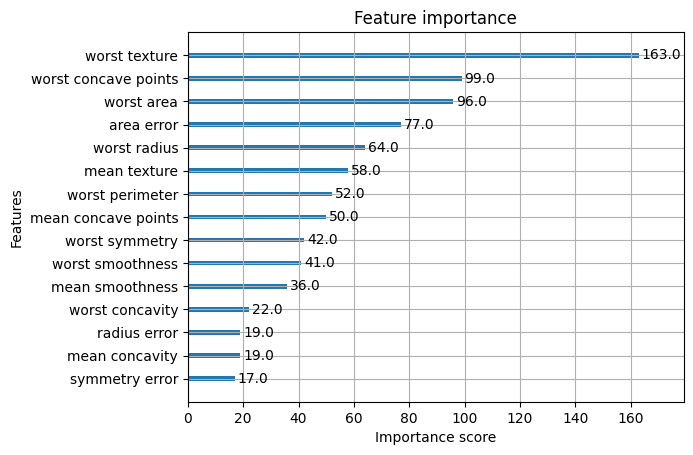

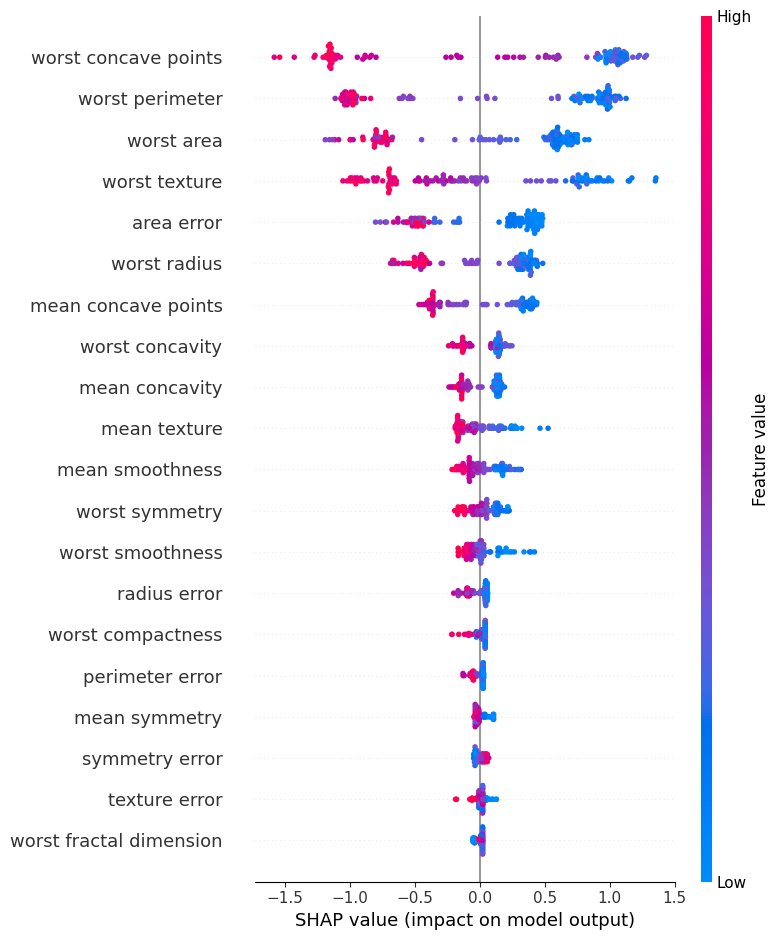

In [22]:
# XGBoost built-in importance
xgb.plot_importance(best_model, max_num_features=15)
plt.show()

# SHAP (recommended for model-agnostic, detailed explanations)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)


In [25]:
# sklearn wrapper: joblib
joblib.dump(best_model, "xgb_best_model.joblib")
loaded = joblib.load("xgb_best_model.joblib")

In [26]:
print("Loaded model test score:", loaded.score(X_test, y_test))

Loaded model test score: 0.9385964912280702


In [27]:
sample_data = {
    "mean radius": [17.5, 11.3],
    "mean texture": [10.1, 20.2],
    "mean perimeter": [120.3, 74.2],
    "mean area": [960.5, 390.1],
    "mean smoothness": [0.099, 0.085],
    "mean compactness": [0.120, 0.045],
    "mean concavity": [0.090, 0.020],
    "mean concave points": [0.060, 0.015],
    "mean symmetry": [0.180, 0.160],
    "mean fractal dimension": [0.062, 0.070],
    "radius error": [0.70, 0.40],
    "texture error": [1.20, 0.60],
    "perimeter error": [5.0, 2.5],
    "area error": [60.0, 20.0],
    "smoothness error": [0.006, 0.004],
    "compactness error": [0.020, 0.015],
    "concavity error": [0.025, 0.010],
    "concave points error": [0.012, 0.006],
    "symmetry error": [0.020, 0.015],
    "fractal dimension error": [0.003, 0.002],
    "worst radius": [21.0, 14.5],
    "worst texture": [15.0, 22.0],
    "worst perimeter": [140.0, 92.0],
    "worst area": [1100.0, 600.0],
    "worst smoothness": [0.110, 0.095],
    "worst compactness": [0.150, 0.060],
    "worst concavity": [0.160, 0.030],
    "worst concave points": [0.090, 0.020],
    "worst symmetry": [0.220, 0.180],
    "worst fractal dimension": [0.070, 0.080]
}

unseen_df = pd.DataFrame(sample_data)

In [28]:
# Predict class labels (0 = malignant, 1 = benign in this dataset)
preds = model.predict(unseen_df)
probs = model.predict_proba(unseen_df)[:, 1]

# Attach results
unseen_df["pred_label"] = preds
unseen_df["pred_proba"] = probs

print(unseen_df[["pred_label", "pred_proba"]])

   pred_label  pred_proba
0           0    0.375357
1           1    0.999445
